# Fourier Transforms

giga mandatory watching
https://www.youtube.com/watch?v=spUNpyF58BY

The initial parts of the notebook will just be a decomposition of fft through that lens

## What is it?

It's a mathematical process for decomposing a complex signal into it's linear sum of sine waves ( constituent pure tone frequencies )

Making the mixed wave?

Let's say I have a signal which is a sum of two freqs of $5$ hz and $3$ hz

$$y(f, t) = cos(2 \pi f t)$$

In [25]:
# making the signal
import numpy as np

f1, f2 = 3, 5

y1 = lambda t: np.cos(2*np.pi*f1 * t)
y2 =lambda t: np.cos(2*np.pi*f2 * t) 
signal = lambda t: y1(t) + y2(t)

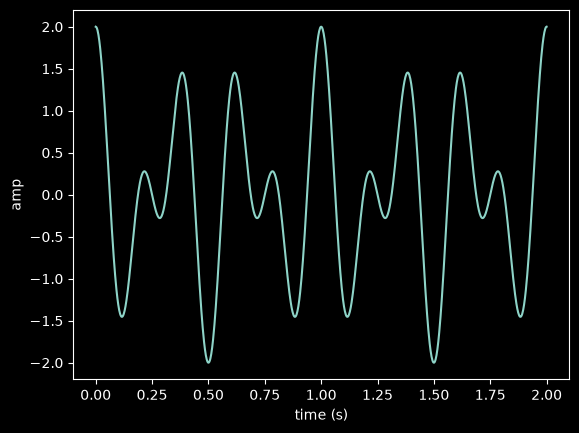

In [26]:
import matplotlib.pyplot as plt
plt.style.use("dark_background") # for my eyes

# to plot I sample some discrete points

t = np.linspace(0, 2, 1000)
y_discrete = signal(t) # the args at np.cos handle both arrays and just a single point

plt.plot(t, signal(t))
plt.xlabel("time (s)")
plt.ylabel("amp")
plt.show()

# Winding a signal around a circle

let's just wrap y1 along the circle, sampling different "segment" lengths ( x-axis ) to wind up

**complex numbers ( quick refresher )**

$e^{i\theta}$ points to the "vector" ( kind of ) in complex plane that is at $\theta$ counter clockwise on a unit circle
what is "arc" length covered? Since well radians is just arc len / radius which is 1 here so that is also the arc length

**back to signal**

Some convention, assume that $f_{wind}$ ( we'll get to it ) and $t=$ so we map 1 sec
of the signal to the cicle and this maps around the whole circle. Ofc we then want
$[0,1] \to [0,2\pi]$ which is just $2\pi t$

unit circle vector * signal => scales that vector so that larger amplitudes are farther off and smaller amplitudes are closer
note that negatives flip it to the opposite quadrant.

but usually we want to control how quickly we wind, so in comes $f_{wind}$, the winding frequency.\
If I want 2 seconds to map around the cirlc ones, I do like
if $f_{wind} = 0.5$ cycles/sec, then in 2 seconds we go
$\theta(2) = 2\pi(0.5)(2) = 2\pi$
so now we can map from $t=0$ to $t=2$ for one full turn

_convention_: usually fourier assumes clockwise rotations so all the angles also have a minus sign

finally we get to
$$z(t) = g(t) \cdot e^{-i 2\pi f_{wind} t}$$

## correction

I got it backwards in the sense that $f_{wind}$ and it's intepretation is correct but when using, we KEEP the segment length fixed and instead change $f_{wind}$, idea being for this fixed len of signal, how many times do you want to repeat it.

This is why I was initially not able to replicate, as I sampled $f_{wind}$ and plotted a different signal window from that, the signal duration itself must remain the same.

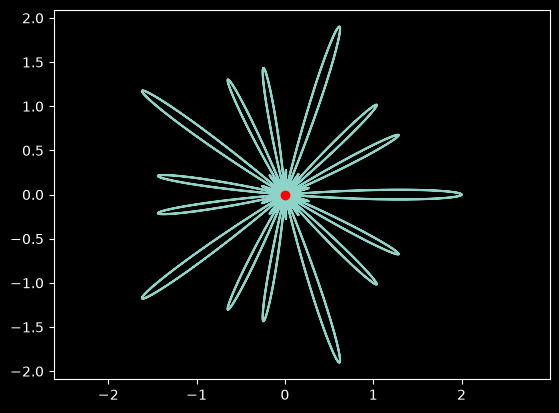

In [27]:
duration = 5
f_wind = 1/duration
# ^^^ this relation does not NEED to hold, for any reason
# what I'm doing for this SPECIFIC cell is 5 sec = 1 circle

def wound_signal(f_wind, duration, signal = signal):
    t_dur = np.linspace(0, duration, 1000 * duration)

    # in python, "j" is the imaginary "i" in maths, so -2j => -2i ( as one literal )
    unit_circle = np.exp(-2j * np.pi * f_wind * t_dur)
    signal_dur = signal(t_dur)

    wound = signal_dur * unit_circle
    com = np.mean(wound)
    return wound, com

wound, com = wound_signal(f_wind, duration)
# plot
# can't use complex directly -> so to x and y vals
def plot_wound_signal(wound, com):
    plt.plot(wound.real, wound.imag)
    plt.plot(com.real, com.imag, "ro") # r = red, o = dot shaped
    plt.axis("equal") # don't change x and y scales when drawing
    plt.show()
plot_wound_signal(wound, com)

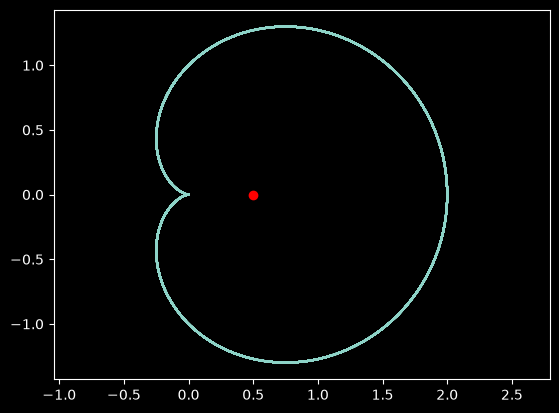

In [28]:
# at the matching freq this changes
# dur is irrelevant
y1_shifted = lambda t: y1(t) + 1 # cardiod, from the vid
# y1 will be just a circle, this is just for matching witht the vid
wound, com = wound_signal(3, 10, signal=y1_shifted)
plot_wound_signal(wound, com)

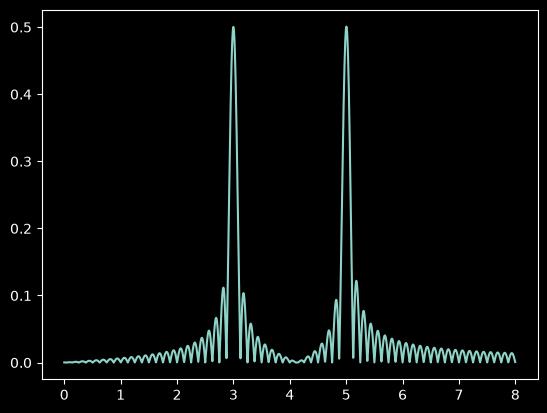

In [29]:
# magnitute of com with f_wind
duration = 8
f_samples = np.linspace(0, duration, 300*duration, endpoint=False) # for div by 0 warnings
distances = [np.abs(wound_signal(f_i, duration)[1]) for f_i in f_samples]

plt.plot(f_samples, distances)
plt.show()

as expected form the vid, we got perfect peaks at 3 and 5, the constituent signal frequencies.

### Ok byt why does it peak?

Look at only where the peaks get mapped on the circle, if you are PERFECTLY in sync, all the peaks get mapped to the SAME point and reinforce the vector.

Com is just an average of all the positions.

chatgpt made me this, look at what point on the unit circle the vec
is drawn at when we are at peaks

> the peaks repeat every $k$ seconds, if you make it so that on the cirlcle, it draws AT THE SAME POINT, you get that re-inforcement, this will happend when $f_{wind} = f_{some\ constituent}$

![Winding Animation](./fourier_winding_animation.gif)

## So it's peaked "visually" but how I define a peak mathematically?

well, you "can" define mathematically but then what does the "almost" peak represent?

Think of fourier transform's "peakness" as the strenght of correlation with the predicted max frequency. If you have a sharp peak then it's almost sure that that is the correct frequency.

Let's not consider any "noise" in the signal, but so far, my scales due to the averaging in com have no notion of a scale. The actual ft does not do a com, instead it just adds those vectors.

Naturally, if you take a longer duration, you have a MUCH higher re-enforcement from all the multiple peaks you observer; on the other hand a short one will have the direction but the size won't have enough count of peaks to have accumulated.

This gives you a "crude" idea of the "uncertainty principle" => a longer time gives you a more confident reading of the signal, a shorter one does not aka it's more peaked vs less peaked.

**isn't it all "analogies"?**

I mean, why not just use com then? Well it works for this case but consider if you have a silence, a com will just average out the whole signal to 0; instead of being more accurate the more information we have.

So in short, you don't average but add as it solves ^ plus gives allows you to "invert" as well ( later )

**but still, how do I say this is peak and not the smaller peaks?**

You can't for certain, unless you sample an inf of the wave, but then what practicallys done is that you use a threshold; obviously this means that based on that you can get a wave with MORE constituents or LESS constituents than original.

It'll be easier in code

## Step 4: does the "angle" of that com ( like ) vec matter?

If my wave $g(t) = A cost( 2\pi f t + \phi)$ started at phi, then note that my peaks will be that that phase ( cos peaks at 0 ), so the com is peaked at that phase, hence
the angle of com gives me the initial phase

# DFT : how it's used practically

A signal can give you the value at any point in time but there is no mathematical construct that can work with arbitrary signals, after all, it can be infinitely complex. So what we do is sample instead.

Note that a mathematical signal is inf dimensional, when you sample N points from it, you make it N dimensional for practical purposes. My N samples which "encode" the freq info live in an N dimensional space, to represent that a sum of constituent frequencies, it's a change of basis and we would again need N as the numer of frequencies to try to match it againt.

> trying to answer how much of 0hz, 1hz, 2hz => freq basis

*argument in this cell is more loose than mathematical* ( I elaborate on this later )

### Getting to $2\pi kn / N$

**why is frequency steps of $f = k/T$**

> DFT assumes the signal segment that we samples from repeats periodically

so say I samples form a "block", dft assumes this is ONE period, not multiple periods, or partial periods and the signal then is meant to repeat like\
`block | block | block ...`

So a phase time diff of $T$ must give me identical position on circle
$e^{i 2\pi f (t+T)} = e^{i 2\pi f t}$
hence $2 \pi f T = 2\pi k$ ( as that addition split to prod with T must be 1 )
which gives us
$$ f = k/T$$

**back to the derivation**

The exp term for a $f_{wind}$ and $t$ time is $e^{-i 2\pi ft}$

Sample interval = $\Delta t$\
Number samples = $N$\
Total time = $T$ = $N \Delta t$

For dft we evaluate for different $f_{k = wind} = k_i / T$ ( from above, N such $k_i$ will be there )

$$2\pi f_k T = 2\pi k_i/T t = 2\pi k_i/(N \Delta t) n \Delta t$$
$$2\pi k_i n / N$$


In [30]:
# making the signal
import numpy as np

f1, f2 = 3, 5

y1 = lambda t: np.cos(2*np.pi*f1 * t)
y2 =lambda t: np.cos(2*np.pi*f2 * t) 
signal = lambda t: y1(t) + y2(t)

# sampling
# nyquist limit => max freq you can detect with sample rate f_s => f_s/2
# so to detect the 5, I need 10
sampling_rate = 10
duration = 5
samples = duration * sampling_rate

t_samples = np.linspace(0,duration, samples, endpoint=False)
sig_samples = signal(t_samples)

sig_samples

array([ 2.        , -1.30901699,  0.19098301, -0.19098301,  1.30901699,
       -2.        ,  1.30901699, -0.19098301,  0.19098301, -1.30901699,
        2.        , -1.30901699,  0.19098301, -0.19098301,  1.30901699,
       -2.        ,  1.30901699, -0.19098301,  0.19098301, -1.30901699,
        2.        , -1.30901699,  0.19098301, -0.19098301,  1.30901699,
       -2.        ,  1.30901699, -0.19098301,  0.19098301, -1.30901699,
        2.        , -1.30901699,  0.19098301, -0.19098301,  1.30901699,
       -2.        ,  1.30901699, -0.19098301,  0.19098301, -1.30901699,
        2.        , -1.30901699,  0.19098301, -0.19098301,  1.30901699,
       -2.        ,  1.30901699, -0.19098301,  0.19098301, -1.30901699])

In code we don't work with physical frequencies, rather freq bin indexes.

Another way to think, and easier imo, is that we assume all the n samples are for N seconds, and then use winding frequencies as 0 to N

why only 0 to N, well any more will map to ONE of the previous ones, it's modulo class

W x signal => test signal against EVERY dft winding frequency

In [31]:
def dft(signal):
    N = len(signal)
    iota = np.arange(N) # 0 to samples, array
    iota_col = iota.reshape((N,1))
    iota_grid = iota_col * iota # N x N grid
    W = np.exp(-2j * np.pi * iota_grid / N)

    # (N,N) x (N,1) => (N,1)
    return W @ signal

X = dft(sig_samples)
X.shape

# for each winding frequency => find the unit vec * winded signal sum


(50,)

### converting freq bin = $k_i$ to physical freq

like I derived, it's just $f_k = k / T$ which is what I do in the next cell

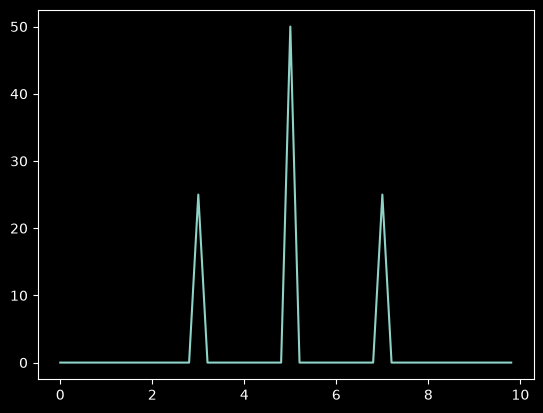

In [33]:
# getting the signals back
mags = np.abs(X)
phys_freq = [1 / duration * idx for idx in range(samples)]

plt.plot(phys_freq,mags)    
plt.show()

## what's that peak at 7?

It's the twin of 3hz => -3hz ( explained a bit later, this is why we LIMIT to only the first half when using DFT results )

I would've gotten ANOTHER peak if I wan't at the nyquist limit ( 10 sampling rate ), this is also why the peak at 5 is twice the 3 peaks as both peaks coincide.

# Relating this conversion to change of basis

a littlle bit of linear algebra follows

say we have $N$ samples, this is the original input in the standard basis of $\mathbb{C}^N$ (real samples are just the special case with zero imaginary part)

If I can find another basis in $\mathbb{C}^N$ then I can do a change of basis. The freq basis we convert to
in fact happens to be not just a basis but an orthogonal one at that.

By proving they are mutually ortho, I can prove that they form a basis for $\mathbb{R}^N$

The basis we are moving to looks like

$$
\mathbf{v}_k =
\begin{bmatrix}
e^{j2\pi k(0)/N} \\
e^{j2\pi k(1)/N} \\
\vdots \\
e^{j2\pi k(N-1)/N}
\end{bmatrix}
$$

$$
basis = \mathbf{v}_0,\mathbf{v}_1,\ldots,\mathbf{v}_{N-1}
$$

Take any two for $n$ and $m$, $v_n$ and $v_m$ are ortho if their dot is zero and since this will be 0 for
any pairs, all pairs are ortho.

Pick the $j_{th}$ row of that column basis

Note the "*" here means conjugate, what I define ahead is the inner product for vectors in complex coeffs. What it'll change is $-i \to i$

$$
\langle \mathbf{v}_k, \mathbf{v}_m \rangle
=
\sum_{n=0}^{N-1}
v_k[n]^* v_m[n]
$$
And
$$
v_k[n]
=
e^{j2\pi kn/N}
$$

$$
\langle \mathbf{v}_k, \mathbf{v}_m \rangle
=
\sum_{n=0}^{N-1}
e^{j2\pi (m-k)n/N}
$$

Let

$$
r = e^{j2\pi (m-k)/N}
$$

Then

$$
\langle \mathbf{v}_k, \mathbf{v}_m \rangle
=
\sum_{n=0}^{N-1} r^n
$$

This is a geometric series, so

$$
\sum_{n=0}^{N-1} r^n
=
\frac{1-r^N}{1-r}
$$

Now,

$$
r^N
=
\left(e^{j2\pi (k-m)/N}\right)^N
=
e^{j2\pi(m-k)}
$$

Since $m-k$ is an integer,

$$
e^{j2\pi(m-k)} = 1
$$

Therefore,

$$
r^N = 1
$$

and for $k \neq m$,

$$
\langle \mathbf{v}_k,\mathbf{v}_m\rangle
=
\frac{1-1}{1-r}
=
0
$$

Thus,

$$
\boxed{
\langle \mathbf{v}_k,\mathbf{v}_m\rangle = 0
\qquad \text{for } k\neq m
}
$$

so every pair of distinct Fourier basis vectors is orthogonal.

For the case $k=m$ ( we NEED to prove they are non zero as well )

$$
\langle \mathbf{v}_k,\mathbf{v}_k\rangle
=
\sum_{n=0}^{N-1}
e^{j2\pi(k-k)n/N}
$$

Since $k-k=0$,

$$
\langle \mathbf{v}_k,\mathbf{v}_k\rangle
=
\sum_{n=0}^{N-1}1
=
N
$$

Therefore,

$$
\boxed{
\langle \mathbf{v}_k,\mathbf{v}_m\rangle
=
\begin{cases}
N, & k=m \\
0, & k\neq m
\end{cases}
}
$$

Since there are $N$ mutually orthogonal, nonzero vectors

$$
\mathbf{v}_0,\mathbf{v}_1,\ldots,\mathbf{v}_{N-1}
$$

in the $N$-dimensional space $\mathbb{C}^N$, they form a basis for $\mathbb{C}^N$.

---

So now we assert that all this is just a change of basis, what remains is to actually see the DFT process as just that, a change of basis ( this naturally shows the invertability as well via a reverse change of basis )

## change of basis refresher

If you have a vector $v$ in basis $B_1$ and you want to conver it to another basis $B_2$ where $B_2$ is orthogonal, you can just project $v$ on each of the $N$ basis vectors in $B_2$, since they are orthogonal no need to worry about the "additives" in same direction from multiple such projections.

> for complex vectors, inner product is not symmatric, there is instead a notion of conjugate symmetric; so here the order matters

$c_k = (v_k, x) / (v_k, v_k) = (v_k, x) / N$ ( as the denom is N )

the $n_{th}$ entry is $v_k[n] = e^{i 2\pi k n / N}$\
accounting for conjugate the proj becomes

$$c_k = 1/N \sum x[n] e^{-i 2\pi k n / N}$$

that $x[n]$ is the $n_{th}$ sample ( just this survives in standard basis )

in my Python code `W @ signal` computes these inner products. The DFT returns $X_k = N c_k$, so it is the change-of-basis coordinates scaled by $N$.


## Nyquist limit from change of basis

Sampling maps a continuous frequency to a vector in $\mathbb{C}^N$. At sample rate $f_s$, the sample times are $t_n=n/f_s$, so frequency $f$ becomes ( this is similar to the $f_k$ derivation but in other direction )

$$
\mathbf{s}_f[n] = e^{i2\pi f n/f_s}.
$$

Now compare it with a frequency one sample rate higher:

$$
\begin{aligned}
\mathbf{s}_{f+f_s}[n]
&= e^{i2\pi(f+f_s)n/f_s} \\
&= e^{i2\pi f n/f_s}e^{i2\pi n} \\
&= e^{i2\pi f n/f_s} \\
&= \mathbf{s}_f[n].
\end{aligned}
$$

The sampler therefore sends infinitely many continuous frequencies to the same vector:

$$
f,\ f+f_s,\ f+2f_s,\ldots\quad\longmapsto\quad\mathbf{s}_f.
$$

This is aliasing as it's called in lin alg aka the sampling map is not one-to-one. Once two frequencies become the same vector, no change of basis can separate them as that info is just lost even prior to DFT.
So we need the $f_s$ to be ATLEAST as high as the max of constituent freqs.

For real signals there is one more identification. A cosine cannot distinguish clockwise from counter-clockwise rotation:

$$
\cos(2\pi f n/f_s)
= \cos(2\pi(f_s-f)n/f_s).
$$

So frequencies above $f_s/2$ mirror back below it. A unique interval of complex frequencies then is

$$
-\frac{f_s}{2} \le f < \frac{f_s}{2},
$$

and for real signals we only care about $0 \le f \le f_s/2$; which is what the Nyquist limit is, that we need sampling to atleast twice the freq that we are tying to detect.
